In [7]:
from HAP import *
from UAV import *
from network_models.users import *
from network_models.cloud_model import *
from network_models.parameters import *
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
import random
from network_models.multi_sat import *

In [2]:
cloud_map = get_full_cloud_torch_20x20().squeeze().cpu().numpy()
clwc_map = get_clwc_map(cloud_map)

alo


In [3]:
cloud_map.shape

(80, 400)

In [4]:
region_t = clwc_map[:, 0:2000+0]


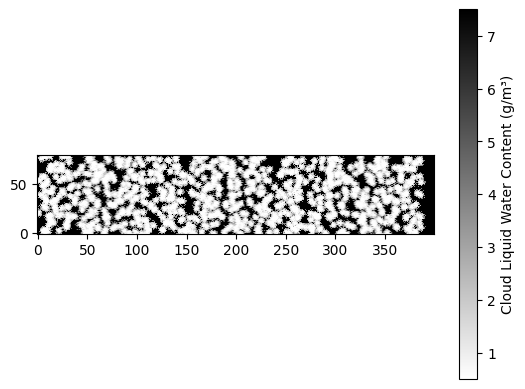

In [5]:
cloud_map = get_full_cloud_torch_20x20()
cloud_map = cloud_map.squeeze().cpu().numpy()

# Hiển thị bản đồ mây
import matplotlib.pyplot as plt
plt.imshow(cloud_map, cmap='gray_r', origin="lower")
plt.colorbar(label='Cloud Liquid Water Content (g/m³)')
plt.show()

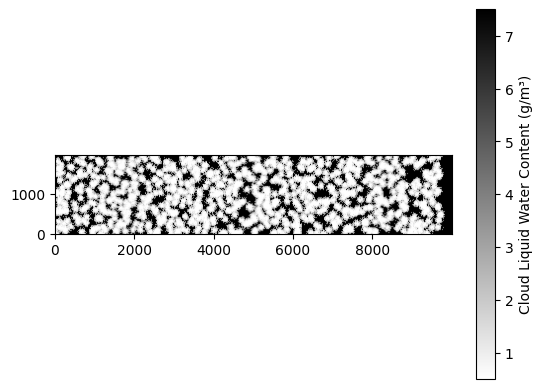

In [6]:
# Hiển thị bản đồ mây
import matplotlib.pyplot as plt
plt.imshow(clwc_map, cmap='gray_r', origin="lower")
plt.colorbar(label='Cloud Liquid Water Content (g/m³)')
plt.show()

In [ ]:
user_positions = simulate_user_mobility(600, 300, n_hotspot=4)


In [12]:
points = user_positions[:,0,:]

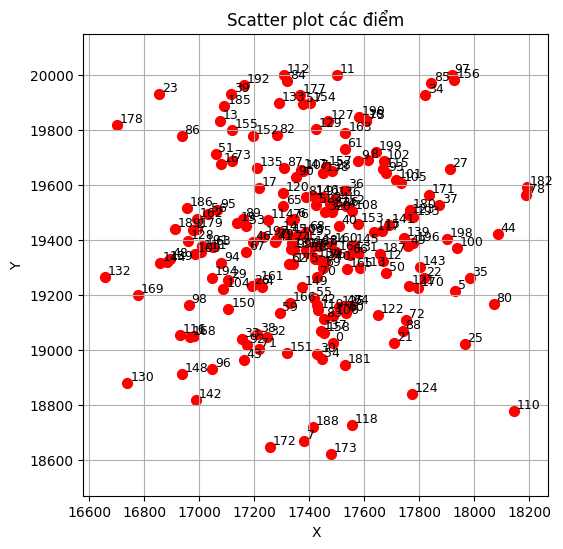

In [13]:
x = points[:, 0]
y = points[:, 1]

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=50, c='red', marker='o')

# Đánh số các điểm cho dễ theo dõi
for i, (xi, yi) in enumerate(points):
    plt.text(xi+10, yi+10, str(i), fontsize=9)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot các điểm")
plt.grid(True)
plt.axis("equal")  # giữ đúng tỷ lệ
plt.show()

In [1]:
import numpy as np

# # Đọc file .npy
# data = np.load("sat_1day.npy", allow_pickle=True)

# print(type(data))   # xem kiểu dữ liệu
# print(data.shape)   # nếu là numpy array thì có shape
# # print(data[:5])     # in thử 5 phần tử đầu

In [2]:
loaded = np.load("sat_1day.npy", allow_pickle=True).item()

print(type(loaded))     # <class 'dict'>
print(loaded.keys())    # các step
print(loaded[list(loaded.keys())[0]])  # dữ liệu step đầu

<class 'dict'>
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

In [ ]:
import numpy as np
import pickle
import random
from tqdm import trange

def load_data(file_in):
    """Tự động load dữ liệu từ npy hoặc pkl"""
    if file_in.endswith(".npy"):
        return np.load(file_in, allow_pickle=True).item()
    elif file_in.endswith(".pkl"):
        with open(file_in, "rb") as f:
            return pickle.load(f)
    else:
        raise ValueError("File phải có đuôi .npy hoặc .pkl")

def build_cache(data, n_cache=3000, n_steps=300, max_trials=1000, reindex=True):
    """Tạo sẵn cache gồm n_cache đoạn hợp lệ"""
    all_steps = sorted(data.keys())
    min_step, max_step = min(all_steps), max(all_steps)

    cache = []
    tried = 0
    for _ in trange(n_cache, desc="Building cache"):
        for _ in range(max_trials):
            start_step = random.randint(min_step, max_step - n_steps)
            segment_raw = {t: data.get(t, []) for t in range(start_step, start_step + n_steps)}

            if all(len(v) > 0 for v in segment_raw.values()):
                if reindex:
                    segment = {i: segment_raw[t] for i, t in enumerate(range(start_step, start_step + n_steps))}
                else:
                    segment = segment_raw
                cache.append(segment)
                break
        else:
            tried += 1
            print(f"⚠️ Không tìm được segment hợp lệ sau {max_trials} lần thử (bỏ qua).")

    print(f"✅ Hoàn thành: {len(cache)} cache hợp lệ, bỏ {tried} lần thất bại.")
    return cache

# ---- MAIN ----
data = load_data("/kaggle/input/sat-1day/sat_1day.npy")
cache = build_cache(data, n_cache=3000, n_steps=301, reindex=True)

# Lưu cache ra file
with open("/kaggle/working/sat_cache_3000.pkl", "wb") as f:
    pickle.dump(cache, f)

print("💾 Cache đã được lưu tại /kaggle/working/sat_cache_3000.pkl")

Min step: 0
Max step: 86399


In [10]:
import numpy as np
import pickle
import random

def load_data(file_in):
    """Tự động load dữ liệu từ npy hoặc pkl"""
    if file_in.endswith(".npy"):
        return np.load(file_in, allow_pickle=True).item()
    elif file_in.endswith(".pkl"):
        with open(file_in, "rb") as f:
            return pickle.load(f)
    else:
        raise ValueError("File phải có đuôi .npy hoặc .pkl")

def get_random_300(file_in, n_steps=300, max_trials=1000, reindex=True):
    """
    Random 1 step bất kỳ và lấy ra n_steps liên tiếp.
    Nếu có step nào rỗng hoặc không đủ thì random lại.
    Nếu reindex=True thì reset key về 0..n_steps-1
    """
    data = load_data(file_in)
    all_steps = sorted(data.keys())
    min_step, max_step = min(all_steps), max(all_steps)

    for _ in range(max_trials):
        start_step = random.randint(min_step, max_step - n_steps)
        segment_raw = {t: data.get(t, []) for t in range(start_step, start_step + n_steps)}

        # kiểm tra có đủ dữ liệu và không rỗng
        if all(len(v) > 0 for v in segment_raw.values()):
            if reindex:
                # reset key về 0..n_steps-1
                segment = {i: segment_raw[t] for i, t in enumerate(range(start_step, start_step + n_steps))}
                return segment
            else:
                return segment_raw

    raise RuntimeError(f"❌ Không tìm được đoạn {n_steps} step hợp lệ sau {max_trials} lần thử")


In [11]:
value = get_random_300("sat_1day.npy", n_steps=300)

In [12]:
print(value)

{0: [('STARLINK-3911           ', np.float64(75.27683747842937), 59, np.float64(537839.2378779021), 0.3606467585187259), ('STARLINK-32430          ', np.float64(68.11311028191008), 29, np.float64(497696.4699593067), 0.37156240919934774), ('STARLINK-6233           ', np.float64(67.13433300209296), 60, np.float64(582668.5316933256), 0.29515140076903484), ('STARLINK-30576          ', np.float64(66.46728605821703), 18, np.float64(586374.6895515157), 0.28938950901844135), ('STARLINK-32238          ', np.float64(65.81233055966253), 22, np.float64(497517.4665623055), 0.3612937159034678), ('STARLINK-3078           ', np.float64(62.67070734761236), 55, np.float64(620644.4505970655), 0.24640741588286869), ('STARLINK-30453          ', np.float64(62.65511914451922), 14, np.float64(605529.3248875793), 0.2569252339238249), ('STARLINK-11224 [DTC]    ', np.float64(56.5719060621283), 13, np.float64(403658.68335075234), 0.40343557676817904)], 1: [('STARLINK-3911           ', np.float64(75.87480984523052